In [24]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
df = pd.read_csv("../../data/processed/clean_dataset.csv")
X = df.values
feature_names = df.columns
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,7/29/2023 13:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,13,7,7
1,8/13/2023 0:11,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,2,0,1,8
2,12/9/2021 10:30,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,10,5,12
3,8/9/2023 19:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5,0,0,5,0,0,19,4,8
4,8/19/2023 14:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,14,7,8


In [26]:
df['most_severe_injury'].unique()

array(['NO INDICATION OF INJURY', 'NONINCAPACITATING INJURY',
       'INCAPACITATING INJURY', 'REPORTED, NOT EVIDENT', 'FATAL'],
      dtype=object)

In [27]:
def map_injury(x):
    if x in ['NO INDICATION OF INJURY', 'REPORTED, NOT EVIDENT']:
        return 'LOW'
    else:
        return 'HIGH'

df['injury_level'] = df['most_severe_injury'].apply(map_injury)
print(df['injury_level'].value_counts())

injury_level
LOW     170840
HIGH     38435
Name: count, dtype: int64


In [28]:
df_low = df[df['injury_level'] == 'LOW']
df_high = df[df['injury_level'] == 'HIGH']

In [29]:
def stratified_sample(df, group_cols, n_total=5000, min_per_group=50, random_state=52):
    df = df.dropna(subset=group_cols)

    # Size & tỷ lệ
    group_sizes = df.groupby(group_cols).size()
    proportions = group_sizes / group_sizes.sum()

    # Sample theo tỷ lệ
    sample_sizes = (proportions * n_total).round().astype(int)

    sampled_df = []

    for group, size in sample_sizes.items():
        group_df = df.copy()

        # Lọc group
        for col, val in zip(group_cols, group if isinstance(group, tuple) else (group,)):
            group_df = group_df[group_df[col] == val]

        if len(group_df) == 0:
            continue

        # Đảm bảo không quá nhỏ
        size = max(size, min_per_group)

        # Không vượt quá dữ liệu thật
        size = min(size, len(group_df))

        sampled_df.append(
            group_df.sample(n=size, random_state=random_state)
        )

    return pd.concat(sampled_df).reset_index(drop=True)

In [30]:
df_low = stratified_sample(df_low, ['weather_condition', 'lighting_condition'])
df_high = stratified_sample(df_high, ['weather_condition', 'lighting_condition'])

In [31]:
features = [
    'weather_condition',        #Thời tiết
    'lighting_condition',       #Ánh sáng
    'roadway_surface_cond',     #Mặt đường
    'trafficway_type',          #Loại đường
    #'alignment',                #Hình dạng đường (thẳng, cong)
    'road_defect',              #Tình trạng đường (ổ gà, trơn trượt) 
    'first_crash_type',         #Loại va chạm đầu tiên (đâm vào, lật xe)
    'prim_contributory_cause',  #Nguyên nhân chính
    'num_units',                #Số lượng phương tiện liên quan
    'crash_hour',               #Giờ xảy ra tai nạn
    'crash_day_of_week',        #Ngày trong tuần (thứ 2, thứ 3, ...)
    'intersection_related_i',   #Có liên quan giao lộ hay không
    'traffic_control_device'    #Thiết bị điều khiển giao thông (đèn đỏ, biển báo)
]

In [32]:
def preprocess(df, features):
    df = df[features].dropna()
    
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    num_cols = df.select_dtypes(exclude=['object']).columns.tolist()
    
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_cat = encoder.fit_transform(df[cat_cols])
    
    scaler = StandardScaler()
    X_num = scaler.fit_transform(df[num_cols])
    
    X = np.hstack([X_cat, X_num])
    
    pca = PCA(n_components=0.95, random_state=52)
    X_pca = pca.fit_transform(X)
    
    feature_names = list(encoder.get_feature_names_out(cat_cols)) + num_cols
    
    return X, X_pca, df, feature_names

In [33]:
from sklearn.metrics import davies_bouldin_score
def run_hac(X_pca, k_range=(2, 6)):
    # Z = linkage(X_pca, method='ward')
    Z = linkage(X_pca, method='complete')
    # Z = linkage(X_pca, method='average')
    results = []
    
    for k in range(*k_range):
        labels = fcluster(Z, t = k, criterion='maxclust')
        
        sil = silhouette_score(X_pca, labels)
        dbi = davies_bouldin_score(X_pca, labels)
        
        results.append({
            "k": k,
            "silhouette": sil,
            "db_index": dbi
        })
        
    return Z, pd.DataFrame(results)
        

In [34]:
def plot_metrics(df, title="HAC Evaluation"):
    fig, axes = plt.subplots(1, 2, figsize=(15,4))

    axes[0].plot(df['k'], df['silhouette'], marker='o')
    axes[0].set_title("Silhouette")

    axes[1].plot(df['k'], df['db_index'], marker='o')
    axes[1].set_title("DB Index")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [36]:
def cluster_profile(df, labels, cat_cols, num_cols):
    df_model = df.copy()
    df_model['cluster'] = labels

    def mode_func(x):
        return x.mode().iloc[0] if not x.mode().empty else None

    cat_profile = df_model.groupby('cluster')[cat_cols].agg(mode_func)
    num_profile = df_model.groupby('cluster')[num_cols].agg(['mean','median'])

    return cat_profile, num_profile

In [37]:
# def plot_density_before(X_pca, title="Before Clustering"):
#     X_2d = PCA(n_components=2).fit_transform(X_pca)

#     plt.figure(figsize=(10,4))
#     plt.subplot(1,2,1)
#     plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.3)
#     plt.title(f"{title} - BEFORE")

#     plt.tight_layout()
#     plt.show()

In [38]:
def plot_dendrogram(Z, title="Dendrogram"):
    plt.figure(figsize=(10,5))

    dendrogram(
        Z,
        truncate_mode='level',  
        p=5                     
    )

    plt.title(title)
    plt.xlabel("Points")
    plt.ylabel("Distance")
    plt.show()

In [ ]:
import seaborn as sns
def run_pipeline(df, name="LOW"):
    print(f"\n===== {name} =====")

    # Preprocess
    X, X_pca, df_clean, feature_names = preprocess(df, features)

    cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
    num_cols = df_clean.select_dtypes(exclude='object').columns.tolist()

    #BEFORE
    # plot_density_before(X_pca, title=f"{name} - Before Clustering")
    
    # HAC
    start_time = time.time()
    Z, eval_df = run_hac(X_pca)
    print(f"HAC Time: {time.time() - start_time:.2f} seconds")
    display(eval_df)

    plot_metrics(eval_df, title=f"{name} - HAC")
    
    # dendrogram
    plot_dendrogram(Z, title=f"{name} - Dendrogram")

    # chọn k tốt nhất (silhouette max)
    best_k = eval_df.loc[eval_df['silhouette'].idxmax(), 'k']
    print("Best k:", best_k)

    labels = fcluster(Z, t=int(best_k), criterion='maxclust')

    # visualize
    X_2d = PCA(n_components=2).fit_transform(X_pca)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='tab10', s=15)
    plt.title(f"{name} - HAC")
    plt.tight_layout()
    plt.show()

    # profile
    cat_profile, num_profile = cluster_profile(df_clean, labels, cat_cols, num_cols)

    print("\nCluster size:")
    print(pd.Series(labels).value_counts())

    print("\nCategorical profile:")
    display(cat_profile)

    print("\nNumeric profile:")
    display(num_profile)
    
    print(f"\n=== {name} - INTERPRETATION HAC ===")

    for c in cat_profile.index:
        print(f"\n--- Cluster {c} ---")

        print("\n[Categorical]")
        print(cat_profile.loc[c].to_string())

        print("\n[Numeric]")
        print(num_profile.loc[c].to_string())


===== LOW =====
HAC Time: 21.19 seconds


,k,silhouette,db_index
0,2,0.260506,1.623305
1,3,0.247217,1.379453
2,4,0.275242,1.305480
3,5,0.260813,1.387528


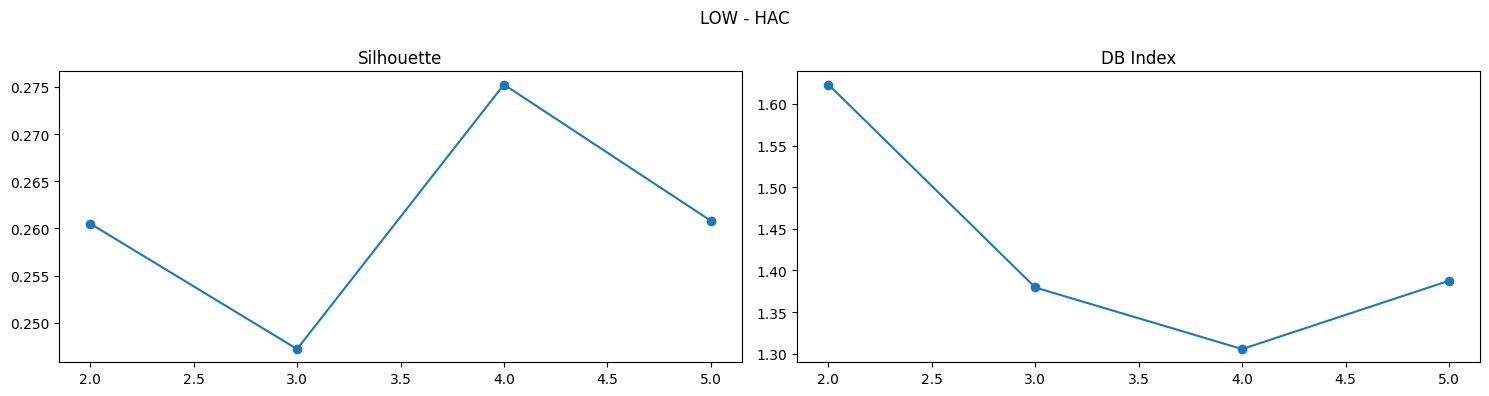

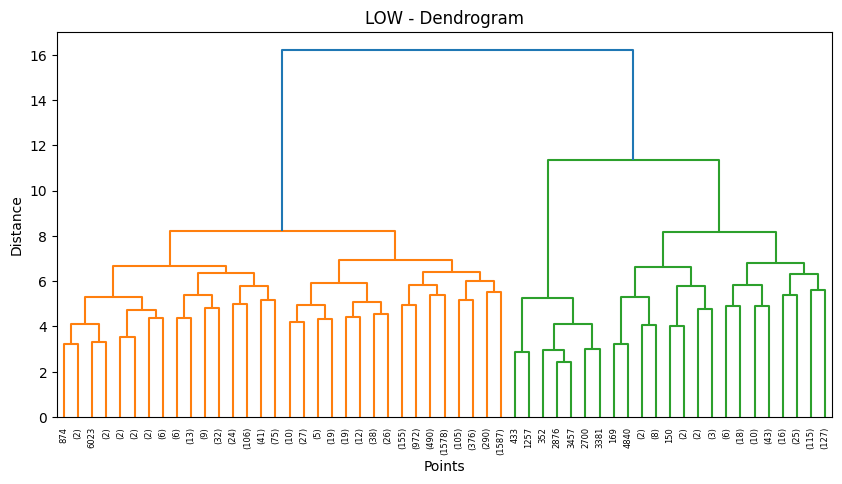

Best k: 4


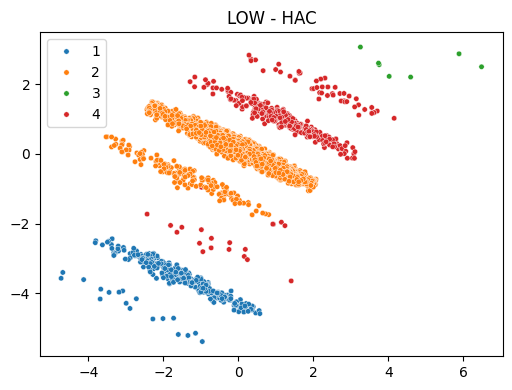


Cluster size:
2    5709
4     380
1     324
3       7
Name: count, dtype: int64

Categorical profile:


,weather_condition,lighting_condition,roadway_surface_cond,trafficway_type,road_defect,first_crash_type,prim_contributory_cause,traffic_control_device
cluster,,,,,,,,
1,CLEAR,DAYLIGHT,DRY,NOT DIVIDED,NO DEFECTS,REAR END,UNKNOWN,NO CONTROLS
2,CLEAR,DAYLIGHT,DRY,NOT DIVIDED,NO DEFECTS,TURNING,UNKNOWN,TRAFFIC SIGNAL
3,CLEAR,DAYLIGHT,DRY,NOT DIVIDED,NO DEFECTS,ANGLE,IMPROPER OVERTAKING/PASSING,STOP SIGN/FLASHER
4,CLEAR,DAYLIGHT,DRY,NOT DIVIDED,NO DEFECTS,ANGLE,UNKNOWN,TRAFFIC SIGNAL



Numeric profile:


num_units        crash_hour        crash_day_of_week         \
             mean median       mean median              mean median   
cluster                                                               
1        1.944444    2.0  12.898148   13.0          4.064815    4.0   
2        1.972675    2.0  13.340165   14.0          4.157120    4.0   
3        5.285714    5.0  18.714286   19.0          4.714286    4.0   
4        3.136842    3.0  13.686842   15.0          4.121053    4.0   

        intersection_related_i         
                          mean median  
cluster                                
1                     0.000000    0.0  
2                     1.000000    1.0  
3                     1.000000    1.0  
4                     0.947368    1.0


=== LOW - INTERPRETATION HAC ===

--- Cluster 1 ---

[Categorical]
weather_condition                CLEAR
lighting_condition            DAYLIGHT
roadway_surface_cond               DRY
trafficway_type            NOT DIVIDED
road_defect                 NO DEFECTS
first_crash_type              REAR END
prim_contributory_cause        UNKNOWN
traffic_control_device     NO CONTROLS

[Numeric]
num_units               mean       1.944444
                        median     2.000000
crash_hour              mean      12.898148
                        median    13.000000
crash_day_of_week       mean       4.064815
                        median     4.000000
intersection_related_i  mean       0.000000
                        median     0.000000

--- Cluster 2 ---

[Categorical]
weather_condition                   CLEAR
lighting_condition               DAYLIGHT
roadway_surface_cond                  DRY
trafficway_type               NOT DIVIDED
road_defect                    NO DEFECTS
first_crash_t

In [40]:
run_pipeline(df_low, "LOW")


===== HIGH =====
HAC Time: 9.07 seconds


,k,silhouette,db_index
0,2,0.615278,0.669206
1,3,0.145319,1.739374
2,4,0.179730,1.520180
3,5,0.179018,1.538710


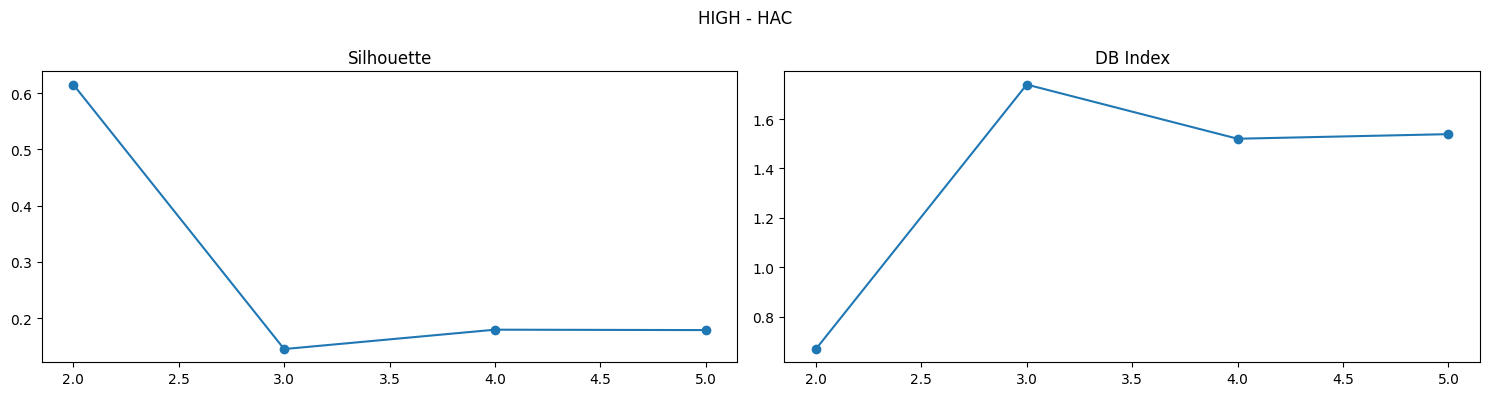

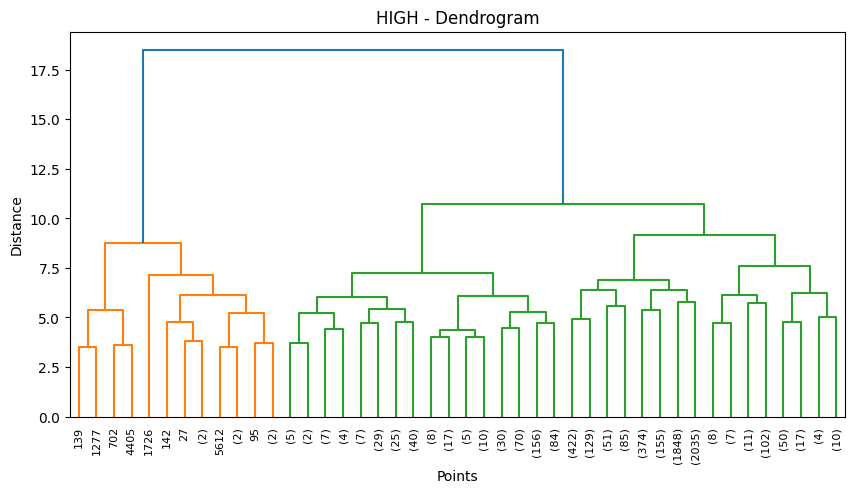

Best k: 2


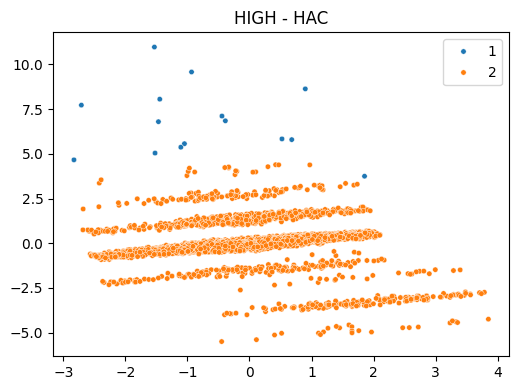


Cluster size:
2    5807
1      15
Name: count, dtype: int64

Categorical profile:


,weather_condition,lighting_condition,roadway_surface_cond,trafficway_type,road_defect,first_crash_type,prim_contributory_cause,traffic_control_device
cluster,,,,,,,,
1,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,NOT DIVIDED,NO DEFECTS,ANGLE,DISREGARDING TRAFFIC SIGNALS,TRAFFIC SIGNAL
2,CLEAR,DAYLIGHT,DRY,NOT DIVIDED,NO DEFECTS,ANGLE,FAILING TO YIELD RIGHT-OF-WAY,TRAFFIC SIGNAL



Numeric profile:


num_units        crash_hour        crash_day_of_week         \
             mean median       mean median              mean median   
cluster                                                               
1        7.133333    7.0   8.600000    6.0          5.000000    6.0   
2        2.111245    2.0  13.149647   14.0          4.075254    4.0   

        intersection_related_i         
                          mean median  
cluster                                
1                     0.933333    1.0  
2                     0.964009    1.0


=== HIGH - INTERPRETATION HAC ===

--- Cluster 1 ---

[Categorical]
weather_condition                                 CLEAR
lighting_condition               DARKNESS, LIGHTED ROAD
roadway_surface_cond                                DRY
trafficway_type                             NOT DIVIDED
road_defect                                  NO DEFECTS
first_crash_type                                  ANGLE
prim_contributory_cause    DISREGARDING TRAFFIC SIGNALS
traffic_control_device                   TRAFFIC SIGNAL

[Numeric]
num_units               mean      7.133333
                        median    7.000000
crash_hour              mean      8.600000
                        median    6.000000
crash_day_of_week       mean      5.000000
                        median    6.000000
intersection_related_i  mean      0.933333
                        median    1.000000

--- Cluster 2 ---

[Categorical]
weather_condition                                  CLEAR
lighting_condition                   

In [41]:
run_pipeline(df_high, "HIGH")